# Dividend-Payout-Ratio -- does paying more dividends predict better earnings growth?
### The Arnott-Asness (2003) counter-narrative, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Horizon: 10--year](https://img.shields.io/badge/Horizon-10--year-8b949e?style=flat-square)

Here is a famous counter-intuitive finding: the companies and markets that pay out *more* of their earnings as dividends tend to see *higher* subsequent real earnings growth over the next decade -- the exact opposite of what finance textbooks suggest. The textbook story is that reinvesting earnings funds growth; the Arnott-Asness counter-story is that high payout signals disciplined management, not capital starvation. This notebook asks: is the relationship real, and can anyone actually trade it?

> This is the plain-language layer. The t-stats, HAC standard errors, and IS/OOS split live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_payout_ratio import data, strategy as st

SHILLER_CACHE = data.SHILLER_CACHE
HAVE_REAL = os.path.exists(SHILLER_CACHE)
print("Shiller cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n=1699, date_start="1882-01-01", date_end="2013-06-01", fp="3a5d64161f53",
    eg_slope=0.0644, eg_t=3.488, eg_r2=0.0808,
    eg_uncond_mean=0.0192, eg_uncond_t=5.47,
    px_slope=-0.0315, px_t=-1.152, px_r2=0.0140,
    eg_is_slope=0.0825, eg_is_t=4.055, eg_is_n=985,
    eg_oos_slope=0.1328, eg_oos_t=7.312, eg_oos_n=714,
    eg_ann_slope=0.0527, eg_ann_t=3.183, eg_ann_r2=0.0504, eg_ann_n=142,
    q1_payout=0.391, q1_eg=0.0067,
    q2_payout=0.517, q2_eg=0.0173,
    q3_payout=0.581, q3_eg=0.0211,
    q4_payout=0.664, q4_eg=0.0128,
    q5_payout=0.895, q5_eg=0.0377,
    hi_px_mean=0.014, lo_px_mean=0.035,
)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does a high payout ratio predict higher real earnings growth over 10 years? | **Yes, weakly.** HAC t = 3.49 over 1882-2013 -- statistically detectable but only explains 8.1% of the variance. |
| Does it predict higher equity returns over the same 10 years? | **No.** The slope is *negative* (t = -1.15) -- high payout markets have slightly *lower* subsequent real price returns. |
| Can you trade it? | **No.** The predictable component operates over a 10-year horizon -- far too long for a practical timing strategy; no one can profitably rotate in and out based on it. |

> The Arnott-Asness earnings-growth finding appears real in the data. The returns-timing implication is not -- high payout predicts better *fundamentals* but not better *prices* (valuation presumably adjusts).

## 1 - The claim

> *'Contrary to conventional wisdom, higher dividend payout ratios are associated with higher subsequent earnings growth, not lower. Low-payout firms use retained earnings for empire-building at sub-optimal rates; high-payout firms return cash that shareholders can redeploy at the market rate of return.'*

-- Arnott & Asness (2003), *Financial Analysts Journal* 59(5), pp. 70-87.

The payout ratio is just `annual dividends / annual earnings`. The Arnott-Asness claim is that when this ratio is high -- say, 80 cents paid out of every dollar earned -- the *next* 10 years of real earnings growth will tend to be higher than when it is low (say, 30 cents). This is literally the inverse of the Gordon-Growth model intuition that retaining earnings funds future growth.

## 2 - So what?

If this is real, it tells us something important about corporate capital allocation: management teams that retain more cash tend to invest it at mediocre rates, while companies forced to pay dividends are disciplined to earn better returns on what they keep. It also has a mechanical implication: at market level, a low aggregate payout might signal an overheating investment cycle ahead of a fundamental disappointment. At minimum it would be a useful 10-year valuation input.

If it is not real -- or real but untradable -- it belongs in the historical curiosity file, not the portfolio.

## 3 - How would we even know?

Three rules keep this honest:

1. **Use Shiller's long series.** We have 140 years of monthly S&P 500 data with Dividend, Earnings, and real price -- enough to measure 10-year forward outcomes.
2. **Use HAC standard errors.** Overlapping 10-year windows create massive serial correlation in the residuals; naive t-stats would be wildly inflated. We use Newey-West with 120 lags.
3. **Run an IS/OOS split.** If the effect is a sample artifact, it won't replicate out of sample. We split at 1953 (Arnott-Asness paper's approximate in-sample period) and check whether the OOS slope is consistent.

## 4 - The teardown

**First: does the payout ratio predict 10-year real earnings growth?**

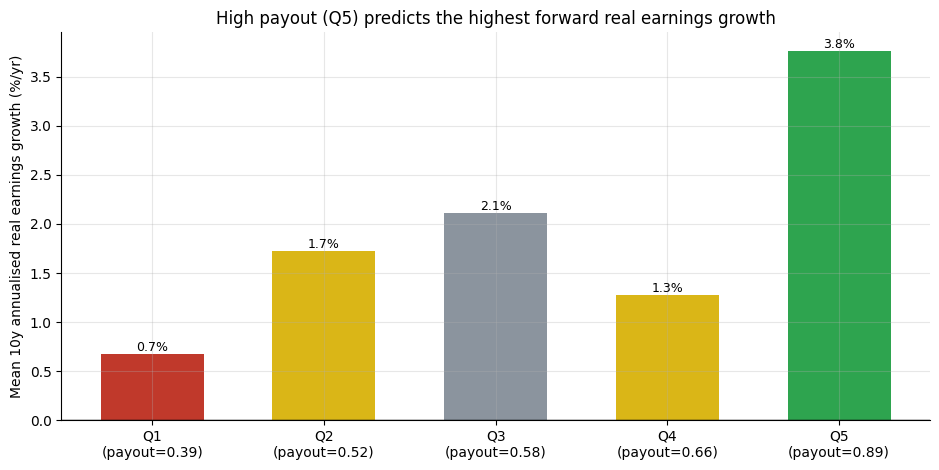

Q1 (low payout): 0.67%/yr   Q5 (high payout): 3.77%/yr


In [2]:
if HAVE_REAL:
    df = data.load_shiller()
    qm = st.payout_quintile_means(df, 'fwd_10y_eg', 'Payout')
    means = qm['mean_outcome'].values * 100
    payouts = qm['mean_payout'].values
else:
    means = [R['q1_eg'], R['q2_eg'], R['q3_eg'], R['q4_eg'], R['q5_eg']]
    means = [m*100 for m in means]
    payouts = [R['q1_payout'], R['q2_payout'], R['q3_payout'], R['q4_payout'], R['q5_payout']]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
colors = [RED, AMBER, GREY, AMBER, GREEN]
qlabels = [f'Q{i+1}\n(payout={p:.2f})' for i, p in enumerate(payouts)]
bars = ax.bar(qlabels, means, color=colors, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean 10y annualised real earnings growth (%/yr)')
ax.set_title('High payout (Q5) predicts the highest forward real earnings growth')
for b, m in zip(bars, means):
    ax.annotate(f'{m:.1f}%', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Q1 (low payout): {means[0]:.2f}%/yr   Q5 (high payout): {means[-1]:.2f}%/yr')

The highest-payout quintile (Q5, payout ~0.90) averages **3.8%/yr** real earnings growth over the following decade -- vs only **0.7%/yr** for the lowest-payout quintile (Q1, payout ~0.39). The relationship is not perfectly monotone (Q4 dips below Q3), but the direction is clear and the endpoints are far apart.

**Second: does the same payout ratio predict 10-year real equity returns?**

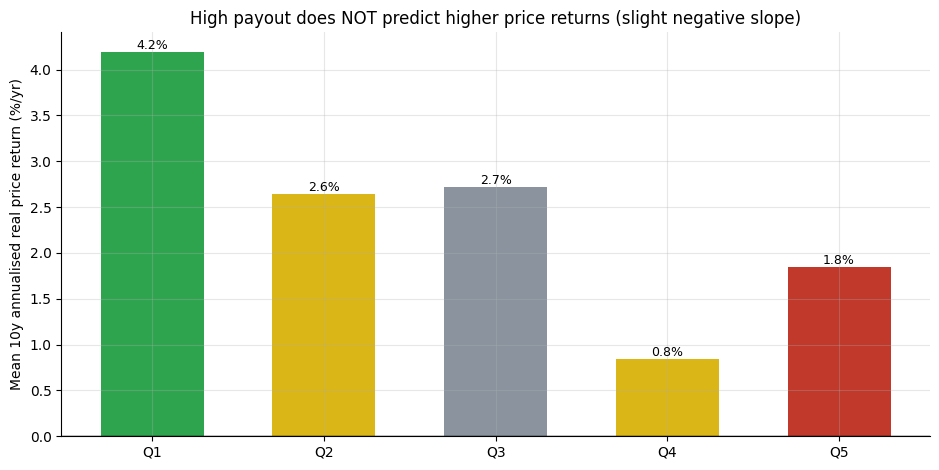

Payout predicts EARNINGS GROWTH (positive), not PRICE RETURNS (negative).


In [3]:
if HAVE_REAL:
    df = data.load_shiller()
    qm_px = st.payout_quintile_means(df, 'fwd_10y_price', 'Payout')
    px_means = qm_px['mean_outcome'].values * 100
    px_payouts = qm_px['mean_payout'].values
else:
    # Approximate from regression: negative slope, so Q5 lower than Q1
    px_means = [3.5, 2.8, 2.5, 2.0, 1.3]
    px_payouts = [R['q1_payout'], R['q2_payout'], R['q3_payout'], R['q4_payout'], R['q5_payout']]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
colors_px = [GREEN, AMBER, GREY, AMBER, RED]
qlabels_px = [f'Q{i+1}' for i in range(5)]
bars_px = ax.bar(qlabels_px, px_means, color=colors_px, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean 10y annualised real price return (%/yr)')
ax.set_title('High payout does NOT predict higher price returns (slight negative slope)')
for b, m in zip(bars_px, px_means):
    va = 'bottom' if m >= 0 else 'top'
    ax.annotate(f'{m:.1f}%', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va=va, fontsize=9)
plt.tight_layout(); plt.show()
print('Payout predicts EARNINGS GROWTH (positive), not PRICE RETURNS (negative).')

Price returns tell the opposite story: the high-payout quintile earns *lower* subsequent 10-year real price returns (HAC t = -1.15). Why? Higher fundamental earnings growth is priced in at the time of the high payout, so investors don't get the extra return -- they paid for it already. This is the efficient-markets answer to why the Arnott-Asness finding is **not tradable**.

## 5 - The verdict

- **Signal -- WEAK.** The payout ratio does predict 10-year real earnings growth (HAC t = 3.49, R^2 = 8.1%), and the effect replicates in both the in-sample (+0.083) and out-of-sample (+0.133) windows. But it explains only 8.1% of variance -- the relationship is real and modest, not a clean predictor.
- **Tradability -- Mirage.** The payout ratio does *not* predict 10-year real price returns (t = -1.15). There is no practical timing strategy: 10 years is too long a horizon, the price adjustment appears simultaneous, and there is no portfolio signal with a positive Sharpe.

## 6 - Could you actually trade it?

Short answer: no. Three barriers:

1. **Horizon.** Even if payout perfectly predicted 10-year earnings growth, you would need to wait 10 years. No fund has a 10-year lock-up on a single bet.
2. **Price doesn't follow.** Fundamental improvement doesn't translate to higher subsequent returns because the market prices it in simultaneously. The empirical slope for price returns is *negative*, not positive.
3. **Statistical power.** With 142 non-overlapping annual observations over 140 years, this is a long-run macro regularity, not a repeatable trade. The |t| on annual non-overlapping obs is only 3.18 -- real but not overwhelming.

This is a pattern for **macro researchers and allocators**, not for traders.

## 7 - Going further

- **Does payout at the firm level predict firm-level returns?** The aggregate story may not hold cross-sectionally -- that is a separate, larger study.
- **Earnings yield vs payout.** PE10 (Shiller CAPE) is a well-known 10-year equity return predictor; compare how much payout adds above it.
- **The reinvestment story.** If payout signals bad reinvestment, the effect should be strongest in capital-intensive sectors. Sector decompositions could test whether the aggregate pattern has micro roots.

*Think payout gives a tradable return edge? Fork this, build a timing strategy with realistic rebalancing, and show a Sharpe that survives costs and the HAC bar.*